In [1]:
import numpy as np
import pandas as pd 
import os 
import matplotlib.pyplot as plt

In [2]:
file_path = "/home/jhkim/NAVA/03_LABEL_BREATH/stored_results/00_detected/20260301/movingwinddetected_patient_03.xlsx"
df = pd.read_excel(file_path)

In [3]:
df.head()

,timestamp,edi,gt_peak,detected_peak,detected_apnea,detected_sigh
0,20,137.23,False,False,False,False
1,30,137.23,False,False,False,False
2,40,139.79,False,False,False,False
3,50,142.12,False,False,False,False
4,60,142.12,False,False,False,False


In [9]:
# print as numpy array
df['edi'][100:1000].values

array([  4.53,   4.53,   4.21,   4.21,   3.91,   3.91,   3.64,   3.4 ,
         3.4 ,   3.21,   3.21,   2.99,   2.86,   2.72,   2.72,   2.54,
         2.54,   2.41,   2.2 ,   2.2 ,   2.07,   2.07,   2.  ,   1.86,
         1.86,   1.83,   1.83,   1.73,   1.67,   1.62,   1.62,   1.58,
         1.58,   1.58,   1.53,   1.49,   1.46,   1.46,   1.43,   1.4 ,
         1.4 ,   1.37,   1.42,   1.42,   1.42,   1.42,   1.36,   1.23,
         1.23,   1.21,   1.22,   1.22,   1.22,   1.22,   1.19,   1.19,
         1.1 ,   1.1 ,   1.14,   1.14,   1.2 ,   1.2 ,   1.2 ,   1.2 ,
         1.2 ,   1.2 ,   1.2 ,   1.2 ,   1.2 ,   1.2 ,   1.2 ,   1.2 ,
         1.2 ,   1.2 ,   1.2 ,   1.2 ,   1.49,   1.49,   1.72,   1.73,
         1.95,   1.95,   2.59,   2.59,   3.33,   4.3 ,   4.3 ,   5.94,
         5.94,   6.53,   6.34,   6.34,   6.46,   6.46,   6.42,   6.46,
         6.46,   6.5 ,   6.5 ,   6.53,   7.09,   7.29,   7.29,   7.47,
         7.47,   7.64,   7.8 ,   7.8 ,   7.94,   7.94,   8.06,   9.1 ,
      

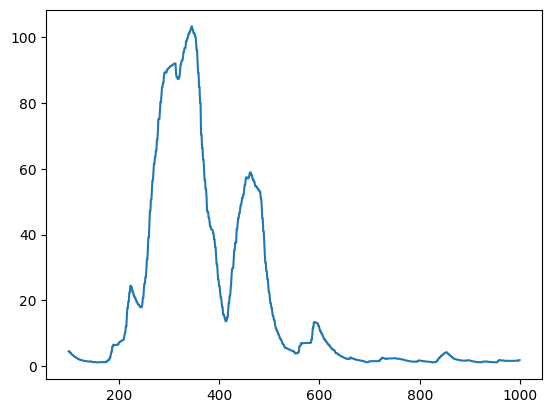

In [10]:
plt.plot(df['edi'][100:1000])

In [11]:
import numpy as np
from scipy.signal import find_peaks

x = df['edi'][100:1000].values

# find peaks
peaks, _ = find_peaks(x, prominence=5)

# sort peaks by height
peaks_sorted = peaks[np.argsort(x[peaks])[::-1]]

# second highest peak
second_peak = peaks_sorted[1]

# define region around peak to remove
left = second_peak
while left > 0 and x[left] > x[left-1]:
    left -= 1

right = second_peak
while right < len(x)-1 and x[right] > x[right+1]:
    right += 1

# interpolate to remove peak
x_clean = x.copy()
x_clean[left:right+1] = np.linspace(x[left], x[right], right-left+1)

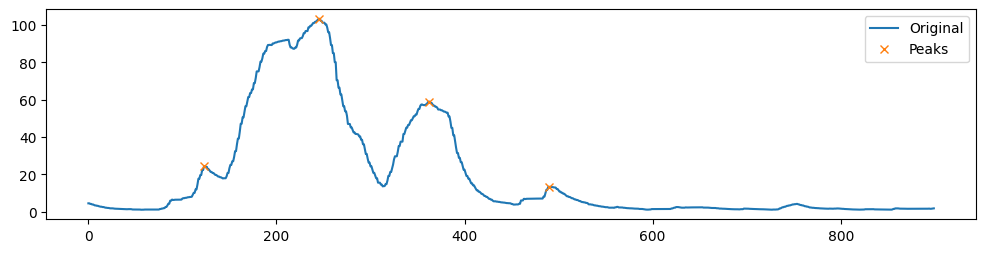

In [13]:
# plot original and cleaned signal
plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.plot(x, label='Original')
plt.plot(peaks, x[peaks], 'x', label='Peaks')
plt.legend()

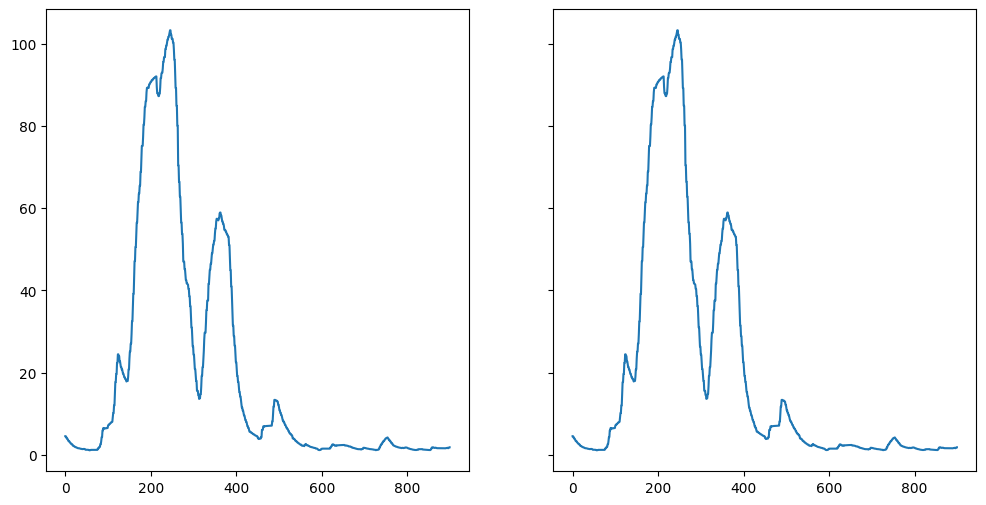

In [16]:
# plot original and cleaned signal
fig, ax = plt.subplots(figsize=(12, 6), ncols=2, sharey=True)
ax[0].plot(x, label='Original')
ax[1].plot(x_clean, label='Cleaned')
